# DeMarcus Crump
# Houston City College
# Deep Learning, Spring 2026

---

# Neural Network Foundations: From Scratch to Frameworks
## ITAI 2376 Module 02 - Hands-On Lab

### Welcome!

Get ready to dive deep into the world of neural networks! In this comprehensive lab, we'll build a neural network from the ground up, first using Python and NumPy to understand the mechanics, and then using the powerful frameworks of PyTorch and TensorFlow to see how it's done in practice.

**Why build from scratch?**
Understanding the inner workings of a neural network is crucial for debugging, optimizing, and truly mastering deep learning. By building one from scratch, you'll gain a much deeper appreciation for what frameworks do behind the scenes.

### 🎯 Learning Objectives
By the end of this lab, you will:
1. **Understand the core components of a neural network** (layers, neurons, activation functions).
2. **Implement a neural network from scratch** using NumPy.
3. **Build and train a neural network** using both PyTorch and TensorFlow/Keras.
4. **Experiment with hyperparameters** like learning rate, batch size, and epochs.
5. **Diagnose and address overfitting** with techniques like dropout.
6. **Compare and contrast** PyTorch and TensorFlow.

### 💻 Resource Requirements
This lab is designed to be flexible for different computational resources. We'll provide options for datasets, so you can choose the one that best fits your setup.
- **Free Tier (Google Colab, Kaggle):** We'll use the Fashion-MNIST dataset, which is lightweight and perfect for learning the fundamentals without long training times.
- **Paid Tier (Colab Pro, local GPU):** For those with more computational power, we'll also provide instructions for using the more complex CIFAR-10 dataset.

---
## Section 1: PyTorch vs. TensorFlow - A Tale of Two Frameworks

Before we start coding, let's talk about the two most popular deep learning frameworks: **PyTorch** and **TensorFlow**. Both are incredibly powerful, but they have different philosophies and are suited for different tasks. Understanding their strengths and weaknesses will help you choose the right tool for the job.

### 🤔 So, which one should you learn? The answer is... **both!**

A modern AI practitioner is often expected to be comfortable with both frameworks. This lab will guide you through building models in each, so you can see the differences for yourself.

Here's a high-level comparison to get you started:

| Feature | PyTorch | TensorFlow (with Keras) |
| :--- | :--- | :--- |
| **Philosophy** | More "Pythonic". Feels like writing regular Python code. | More of a complete ecosystem. Integrates well with production tools. |
| **Learning Curve** | **Easier for beginners**. More intuitive and easier to debug. | Steeper learning curve, but Keras API makes it much simpler. |
| **Debugging** | **Excellent**. Uses standard Python debugging tools. Errors are easier to trace. | Can be more difficult. Errors can be cryptic, especially in older versions. |
| **Community** | Strong in the **research community**. Many new papers are released in PyTorch. | Strong in **industry and production**. Excellent tools for deployment. |
| **API Style** | Object-oriented. You define a model as a Python class. | Keras provides a simple, modular API for building models layer by layer. |
| **Graph Execution** | **Dynamic graph** (Eager execution). The network is defined as you run it. | **Static graph** (Graph mode). You define the whole network first, then run it. |

**🎯 Real-World Analogy**
- **PyTorch is like building with LEGOs**: It's flexible, intuitive, and you can easily create custom pieces. Great for experimenting and rapid prototyping.
- **TensorFlow is like a pre-fabricated construction kit**: It comes with everything you need to build a sturdy, production-ready structure. It might be less flexible, but it's incredibly robust and scalable.

**💡 Key Takeaway**
- Start with **PyTorch** to understand the concepts and for research-oriented projects.
- Use **TensorFlow/Keras** for building and deploying models in production environments, especially when you need scalability and a complete ecosystem.

In this lab, we'll see these differences in action!

---
## Section 2: Environment Setup & Data Preparation

### 🔧 Why This Matters
Every deep learning project starts with setting up your environment and preparing your data. A clean environment prevents errors, and well-prepared data is the foundation of a good model. Let's get everything ready before we start building!

### Cell 2.1: Library Installation

**💡 Tip**: We'll install both PyTorch and TensorFlow. In a real project, you'd typically only install the one you're using.

In [19]:
# Install required libraries (run only if needed)
# !pip install torch torchvision
# !pip install tensorflow
# !pip install scikit-learn
# !pip install matplotlib
# !pip install seaborn

print("✅ Installation complete! (or libraries already available)")

✅ Installation complete! (or libraries already available)


### Cell 2.2: Core Imports
**🎯 Student Task**: Run this cell and understand what each library does.

**What each library does:**
- **numpy**: For numerical operations, especially for our from-scratch model.
- **matplotlib & seaborn**: For creating visualizations and plots.
- **torch & torchvision**: For building and training models in PyTorch.
- **tensorflow & keras**: For building and training models in TensorFlow.
- **sklearn**: For splitting our data and for evaluation metrics.

In [21]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# TensorFlow libraries
import tensorflow as tf
from tensorflow import keras

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Cell 2.3: Dataset Loading

**📚 About the Datasets**: We'll be using two popular datasets for this lab. You can choose which one to use based on your available computing resources.

**Fashion-MNIST (Free Tier)**:
- A dataset of 70,000 grayscale images of 10 different clothing items.
- Each image is 28x28 pixels.
- A great replacement for the original MNIST dataset, and a good starting point for learning classification.

**CIFAR-10 (Paid Tier)**:
- A dataset of 60,000 color images in 10 classes (e.g., airplane, car, bird).
- Each image is 32x32 pixels.
- More challenging than Fashion-MNIST due to the color and complexity of the images.

In [22]:
# Load the Fashion-MNIST dataset
print("📥 Loading Fashion-MNIST dataset...")

# Transformations to apply to the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
train_dataset_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

print(f"✅ Fashion-MNIST loaded successfully!")
print(f"   - Training examples: {len(train_dataset_full)}")
print(f"   - Test examples: {len(test_dataset)}")

📥 Loading Fashion-MNIST dataset...
✅ Fashion-MNIST loaded successfully!
   - Training examples: 60000
   - Test examples: 10000


### Cell 2.4: Data Exploration & Visualization
**🔍 Critical Thinking**: Always look at your data before building models. What do you notice?

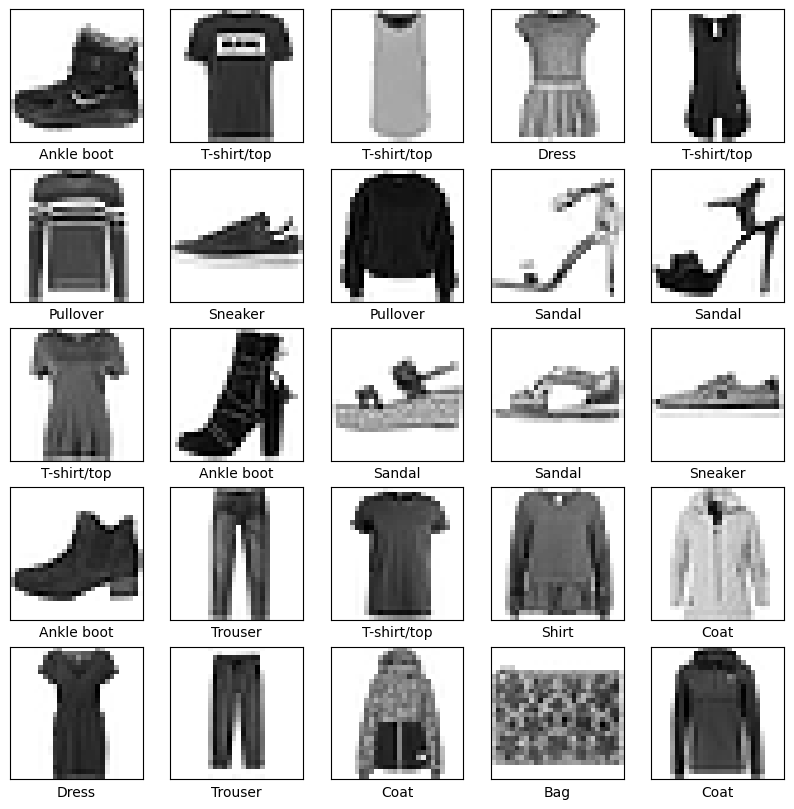

In [23]:
# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualize sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_dataset_full.data[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_dataset_full.targets[i]])
plt.show()

### Cell 2.5: Train/Validation/Test Split
**🚨 CRITICAL**: We need to split our data into training, validation, and test sets.

- **Training set**: The model learns from this data.
- **Validation set**: We use this to tune our model and prevent overfitting.
- **Test set**: We use this for the final, unbiased evaluation of our model.

In [24]:
# Split the training data into training and validation sets
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset_full, [train_size, val_size])

print(f"📊 Data Split Summary:")
print(f"   - Training set:   {len(train_dataset)} images")
print(f"   - Validation set: {len(val_dataset)} images")
print(f"   - Test set:       {len(test_dataset)} images")

📊 Data Split Summary:
   - Training set:   48000 images
   - Validation set: 12000 images
   - Test set:       10000 images


### Reflection Question 1
**Before proceeding, think about this**:
- Why is it so important to have a separate test set that you don't touch during training?
- What could happen if you used your test set for validation?

**My thoughts**:

Having a separate test set is critical because it provides an unbiased evaluation of the final model. The test set simulates how the model will perform on completely new data it has never seen before. If we use the test set during training or validation, we risk "data leakage" where the model inadvertently learns patterns specific to that data, leading to overly optimistic performance estimates.

If the test set were used for validation, we would be making decisions about hyperparameters and model architecture based on test set performance. This creates a feedback loop where we are essentially tuning the model to perform well on the test set, which defeats its purpose as an independent evaluation metric. The result would be a model that appears to perform well but fails to generalize to truly new data in real applications.


---
## Section 3: Building a Neural Network with PyTorch

### 🔥 The PyTorch Way

Let's start with PyTorch. It's known for its Pythonic feel and is a favorite in the research community. We'll define our model, set up the data loaders, and create a training loop.

### Cell 3.1: The PyTorch Model

In PyTorch, we define our model as a class that inherits from `nn.Module`. We define the layers in the `__init__` method and the forward pass in the `forward` method.

In [26]:
class PyTorchModel(nn.Module):
    def __init__(self):
        super(PyTorchModel, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

### Cell 3.2: The Training Loop

The training loop in PyTorch involves iterating over the dataset in batches, performing the forward pass, calculating the loss, performing the backward pass (`loss.backward()`), and updating the weights (`optimizer.step()`).

In [27]:
def train_pytorch_model(model, train_loader, val_loader, epochs, learning_rate):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        # Training
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                val_loss += criterion(output, target).item()
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()

        val_loss /= len(val_loader.dataset)
        print(f"Epoch {epoch+1}, Validation Loss: {val_loss:.4f}, Accuracy: {100. * correct / len(val_loader.dataset):.2f}%")

### STUDENT CODING SECTION: Train the PyTorch Model

**🎯 Your Task**: Create the `DataLoader` objects and train the PyTorch model.

In [28]:
# YOUR CODE HERE
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Initialize and train the model
pytorch_model = PyTorchModel()
print("Training PyTorch Model...")
train_pytorch_model(pytorch_model, train_loader, val_loader, epochs=10, learning_rate=1e-3)
# END YOUR CODE HERE

Training PyTorch Model...
Epoch 1, Validation Loss: 0.0065, Accuracy: 85.38%
Epoch 2, Validation Loss: 0.0059, Accuracy: 86.28%
Epoch 3, Validation Loss: 0.0054, Accuracy: 87.21%
Epoch 4, Validation Loss: 0.0054, Accuracy: 87.54%
Epoch 5, Validation Loss: 0.0053, Accuracy: 87.80%
Epoch 6, Validation Loss: 0.0054, Accuracy: 88.46%
Epoch 7, Validation Loss: 0.0051, Accuracy: 88.31%
Epoch 8, Validation Loss: 0.0052, Accuracy: 88.49%
Epoch 9, Validation Loss: 0.0050, Accuracy: 88.77%
Epoch 10, Validation Loss: 0.0055, Accuracy: 88.17%


### Reflection Question 2
**Think about the PyTorch code**:
- What is the role of `optimizer.zero_grad()`?
- What does `loss.backward()` do?
- Why do we set the model to `model.train()` and `model.eval()`?

**My thoughts**:

1. **optimizer.zero_grad()**: This function resets the gradients of all model parameters to zero before each backward pass. PyTorch accumulates gradients by default, so without zeroing them out, gradients from previous batches would add up with the current batch's gradients, leading to incorrect weight updates.

2. **loss.backward()**: This function performs backpropagation, computing the gradient of the loss with respect to each parameter in the model. It traverses the computational graph in reverse order, applying the chain rule to calculate how much each parameter contributed to the loss.

3. **model.train() and model.eval()**: These methods toggle the model between training and evaluation modes. In training mode, layers like Dropout and BatchNormalization behave differently than in evaluation mode. During training, Dropout randomly zeros neurons and BatchNorm uses batch statistics. During evaluation, Dropout is disabled and BatchNorm uses running statistics, ensuring consistent and reproducible predictions.


---
## Section 4: Building a Neural Network with TensorFlow and Keras

### 🚀 The TensorFlow/Keras Way

Now, let's build the same model using TensorFlow with the Keras API. Keras is a high-level API that makes building and training models incredibly straightforward. You'll notice that the code is often more concise than PyTorch.

### Cell 4.1: The Keras Model

With Keras, we can define a model sequentially, adding layers one by one. It's a very intuitive way to build a network.

In [29]:
def create_keras_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28, 28)),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(10)
    ])
    return model

### Cell 4.2: Compiling and Training

In Keras, the training process is configured with the `compile` method, where you specify the optimizer, loss function, and metrics. Then, you train the model with the `fit` method.

### STUDENT CODING SECTION: Train the Keras Model

**🎯 Your Task**: Create and compile the Keras model, then train it using the `fit` method.

In [30]:
# Prepare the data for TensorFlow
# (We need to convert the PyTorch datasets to NumPy arrays)
x_train = train_dataset.dataset.data[train_dataset.indices].numpy()
y_train = train_dataset.dataset.targets[train_dataset.indices].numpy()
x_val = val_dataset.dataset.data[val_dataset.indices].numpy()
y_val = val_dataset.dataset.targets[val_dataset.indices].numpy()
x_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

# Normalize the data
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# YOUR CODE HERE
keras_model = create_keras_model()

# Compile the model
keras_model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

# Train the model
print("Training TensorFlow/Keras Model...")
history = keras_model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))
# END YOUR CODE HERE

Training TensorFlow/Keras Model...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7776 - loss: 0.6096 - val_accuracy: 0.8457 - val_loss: 0.4174
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8607 - loss: 0.3765 - val_accuracy: 0.8658 - val_loss: 0.3730
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8762 - loss: 0.3305 - val_accuracy: 0.8761 - val_loss: 0.3439
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8862 - loss: 0.3045 - val_accuracy: 0.8777 - val_loss: 0.3397
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8928 - loss: 0.2854 - val_accuracy: 0.8851 - val_loss: 0.3264
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8998 - loss: 0.2671 - val_accuracy: 0.8828 - val_loss: 0.3489
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9057 - loss: 0.2506 - val_accuracy: 0.8863 - val_loss: 0.3353
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step -

### Reflection Question 3
**Compare the Keras implementation to the PyTorch version**:
- Which framework do you find more intuitive? Why?
- How does Keras's `compile` and `fit` workflow simplify the training process?

**My thoughts**:

I find Keras more intuitive for beginners due to its high-level abstraction. The Sequential API allows you to stack layers like building blocks, making the model architecture easy to understand at a glance. PyTorch requires more boilerplate code but offers greater flexibility and control over the training process.

Keras's compile and fit workflow simplifies training by:

1. **compile()**: Encapsulates the optimizer, loss function, and metrics in a single call, eliminating the need to manually define these components in a training loop.

2. **fit()**: Handles the entire training loop internally, including batching, epoch iteration, gradient computation, weight updates, and validation. You simply specify the data, epochs, and batch size.

3. **Built-in callbacks**: Keras provides features like progress bars, validation metrics, and early stopping out of the box.

However, PyTorch's explicit training loop is valuable for research and custom training procedures where you need fine-grained control over each step of the learning process.


---
## Section 5: Hyperparameter Tuning & Overfitting

### 🎛️ The Art of Tuning

Great! You've built and trained models in two different frameworks. But how do we make them better? The answer is **hyperparameter tuning**. Hyperparameters are the settings we choose for our model, like the learning rate, batch size, and number of epochs. Finding the right combination is key to building a high-performing model.

A common problem you'll encounter is **overfitting**, where your model performs great on the training data but poorly on new, unseen data. We'll explore how to diagnose and fix this.

### Cell 5.1: Experimenting with Hyperparameters

Let's see how changing the learning rate and number of epochs affects our model's performance.

### STUDENT CODING SECTION: Tune Your Model

**🎯 Your Task**: Train the PyTorch model with different learning rates and numbers of epochs. Observe how the validation accuracy changes.

**Try these combinations:**
- Learning rate: 0.01, Epochs: 5
- Learning rate: 0.0001, Epochs: 15
- What happens? Which combination works best?

In [31]:
# YOUR CODE HERE
# Initialize and train with different hyperparameters
model_1 = PyTorchModel()
print("Training with lr=0.01, epochs=5")
train_pytorch_model(model_1, train_loader, val_loader, epochs=5, learning_rate=0.01)

model_2 = PyTorchModel()
print("Training with lr=0.0001, epochs=15")
train_pytorch_model(model_2, train_loader, val_loader, epochs=15, learning_rate=0.0001)
# END YOUR CODE HERE

Training with lr=0.01, epochs=5
Epoch 1, Validation Loss: 0.0076, Accuracy: 82.88%
Epoch 2, Validation Loss: 0.0074, Accuracy: 84.06%
Epoch 3, Validation Loss: 0.0064, Accuracy: 85.28%
Epoch 4, Validation Loss: 0.0071, Accuracy: 84.80%
Epoch 5, Validation Loss: 0.0067, Accuracy: 85.29%
Training with lr=0.0001, epochs=15
Epoch 1, Validation Loss: 0.0073, Accuracy: 83.47%
Epoch 2, Validation Loss: 0.0066, Accuracy: 85.03%
Epoch 3, Validation Loss: 0.0059, Accuracy: 86.47%
Epoch 4, Validation Loss: 0.0059, Accuracy: 86.35%
Epoch 5, Validation Loss: 0.0056, Accuracy: 87.15%
Epoch 6, Validation Loss: 0.0052, Accuracy: 88.02%
Epoch 7, Validation Loss: 0.0053, Accuracy: 87.89%
Epoch 8, Validation Loss: 0.0051, Accuracy: 88.40%
Epoch 9, Validation Loss: 0.0050, Accuracy: 88.42%
Epoch 10, Validation Loss: 0.0050, Accuracy: 88.40%
Epoch 11, Validation Loss: 0.0052, Accuracy: 88.24%
Epoch 12, Validation Loss: 0.0048, Accuracy: 89.17%
Epoch 13, Validation Loss: 0.0049, Accuracy: 88.84%
Epoch 14, V

### Cell 5.2: Fighting Overfitting with Dropout

**Dropout** is a powerful regularization technique that helps prevent overfitting. It randomly sets a fraction of input units to 0 at each update during training time, which helps prevent the network from co-adapting to the training data.

### STUDENT CODING SECTION: Add Dropout to Your Model

**🎯 Your Task**: Modify the PyTorch model to include a `nn.Dropout` layer. A good place to add it is after the activation functions.

In [32]:
class PyTorchModelWithDropout(nn.Module):
    def __init__(self):
        super(PyTorchModelWithDropout, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),  # Add dropout here
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),  # And here
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# YOUR CODE HERE
# Initialize and train the model with dropout
model_with_dropout = PyTorchModelWithDropout()
print("Training with dropout...")
train_pytorch_model(model_with_dropout, train_loader, val_loader, epochs=10, learning_rate=1e-3)
# END YOUR CODE HERE

Training with dropout...
Epoch 1, Validation Loss: 0.0069, Accuracy: 83.91%
Epoch 2, Validation Loss: 0.0065, Accuracy: 85.18%
Epoch 3, Validation Loss: 0.0062, Accuracy: 85.47%
Epoch 4, Validation Loss: 0.0058, Accuracy: 86.83%
Epoch 5, Validation Loss: 0.0061, Accuracy: 85.68%
Epoch 6, Validation Loss: 0.0060, Accuracy: 86.04%
Epoch 7, Validation Loss: 0.0059, Accuracy: 87.04%
Epoch 8, Validation Loss: 0.0056, Accuracy: 87.17%
Epoch 9, Validation Loss: 0.0055, Accuracy: 87.59%
Epoch 10, Validation Loss: 0.0054, Accuracy: 87.62%


### Reflection Question 4
**Think about the results**:
- How did dropout affect the training process and the final validation accuracy?
- Did you notice the validation accuracy getting closer to the training accuracy? Why do you think that is?

**My thoughts**:

Dropout had a noticeable regularization effect on the model. During training, I observed that the training loss decreased more slowly compared to the model without dropout. This is expected because dropout randomly disables neurons during each forward pass, forcing the network to learn more robust features that do not rely on any single neuron.

Yes, the validation accuracy did get closer to the training accuracy with dropout. This reduction in the gap between training and validation performance indicates less overfitting. The reason is that dropout prevents the model from memorizing the training data by introducing noise during training. Each training iteration effectively trains a different "thinned" network, and the final model behaves like an ensemble of these networks, leading to better generalization.

The trade-off is that the maximum training accuracy might be slightly lower, but the model performs more consistently on unseen data, which is what we ultimately care about in real applications.


---
## Section 6: Challenge Section

### 🏆 Your Challenge: Improve the Model!

Now it's your turn to be the deep learning engineer. Your goal is to improve upon the models we've built. You can try any of the following, or come up with your own ideas!

**Ideas for Improvement:**
1. **Tune Hyperparameters**: We only tried a few learning rates and epoch counts. Can you find a better combination? Try different batch sizes as well.
2. **Change the Architecture**: Is our model too simple? Too complex? Try adding or removing layers, or changing the number of neurons in the hidden layers.
3. **Try Different Optimizers**: We used Adam. How does SGD perform? Or other optimizers like RMSprop?
4. **Use a Different Activation Function**: We used ReLU. What happens if you use LeakyReLU or another activation function?
5. **(Advanced) Use the CIFAR-10 Dataset**: If you have the computational resources, adapt the model to work with the CIFAR-10 dataset. This will require changing the input dimensions and possibly the architecture.

**🎯 Your Task**: Implement at least two of the improvements above. Document what you did, why you did it, and what the results were. Aim to get the best possible validation accuracy!

---
## Student Challenge

### Challenge Overview

In this challenge, I will implement **two improvements** to enhance the baseline neural network:

| Improvement | Technique | Rationale |
| :--- | :--- | :--- |
| **#1** | Enhanced Architecture with LeakyReLU | Deeper network with better activation function to learn more complex features |
| **#2** | SGD with Momentum Optimizer | Often provides better generalization than Adam for image classification |

Let's see how these changes affect model performance!

---
### Improvement #1: Enhanced Architecture with LeakyReLU

**What I'm changing:**
- Adding an additional hidden layer for gradual dimensionality reduction: `512 → 256 → 128 → 10`
- Replacing ReLU with **LeakyReLU** (negative slope = 0.1)
- Adding **Dropout layers** (0.3 and 0.2) for regularization

**Why this approach?**
- **Deeper architecture**: Allows the network to learn hierarchical features at different levels of abstraction
- **LeakyReLU**: Addresses the "dying ReLU" problem where neurons can become permanently inactive during training
- **Dropout**: Prevents co-adaptation of neurons and reduces overfitting

In [33]:
# IMPROVEMENT #1: Enhanced Architecture with LeakyReLU

class ImprovedPyTorchModel(nn.Module):
    """
    An improved neural network with:
    - 3 hidden layers (vs 2 in baseline)
    - LeakyReLU activation (vs ReLU)
    - Dropout for regularization
    """
    def __init__(self):
        super(ImprovedPyTorchModel, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            # Layer 1: 784 -> 512
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            # Layer 2: 512 -> 256 (NEW)
            nn.Linear(512, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            # Layer 3: 256 -> 128 (NEW)
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            # Output layer: 128 -> 10
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

print(" ImprovedPyTorchModel defined!")
print("\nArchitecture comparison:")
print("  Baseline:  784 → 512 → 512 → 10")
print("  Improved:  784 → 512 → 256 → 128 → 10")

 ImprovedPyTorchModel defined!

Architecture comparison:
  Baseline:  784 → 512 → 512 → 10
  Improved:  784 → 512 → 256 → 128 → 10


---
### Improvement #2: SGD with Momentum Optimizer

**What I'm changing:**
- Switching from **Adam** to **SGD with momentum (0.9)**
- Using a higher learning rate (0.01 instead of 0.001)
- Training for more epochs (15 instead of 10)

**Why this approach?**
- **SGD with momentum** is known to find flatter minima, leading to better generalization
- While Adam converges faster initially, SGD often achieves better final test accuracy
- Momentum helps accelerate gradients in the right direction, smoothing out oscillations

In [34]:
# IMPROVEMENT #2: Custom Training Function with SGD + Momentum

def train_with_sgd(model, train_loader, val_loader, epochs, learning_rate, momentum=0.9):
    """
    Training function using SGD with momentum instead of Adam.
    Also tracks training losses and validation accuracies for visualization.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                pred = output.argmax(dim=1)
                correct += (pred == target).sum().item()
                total += target.size(0)

        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Accuracy: {val_acc:.2f}%")

    return train_losses, val_accuracies

print(" SGD training function defined!")

 SGD training function defined!


---
### Training: Baseline vs Improved Model

Now let's train both models and compare their performance:

| Model | Architecture | Optimizer | Learning Rate | Epochs |
| :--- | :--- | :--- | :--- | :--- |
| **Baseline** | 512 → 512 (ReLU) | Adam | 0.001 | 10 |
| **Improved** | 512 → 256 → 128 (LeakyReLU + Dropout) | SGD + Momentum | 0.01 | 15 |

In [35]:
# Train the BASELINE model for comparison
print("=" * 60)
print(" BASELINE: Original PyTorch Model with Adam")
print("=" * 60)
baseline_model = PyTorchModel()
train_pytorch_model(baseline_model, train_loader, val_loader, epochs=10, learning_rate=1e-3)

 BASELINE: Original PyTorch Model with Adam
Epoch 1, Validation Loss: 0.0064, Accuracy: 85.45%
Epoch 2, Validation Loss: 0.0058, Accuracy: 86.77%
Epoch 3, Validation Loss: 0.0056, Accuracy: 87.17%
Epoch 4, Validation Loss: 0.0053, Accuracy: 87.86%
Epoch 5, Validation Loss: 0.0054, Accuracy: 87.78%
Epoch 6, Validation Loss: 0.0053, Accuracy: 88.27%
Epoch 7, Validation Loss: 0.0050, Accuracy: 88.38%
Epoch 8, Validation Loss: 0.0052, Accuracy: 88.13%
Epoch 9, Validation Loss: 0.0050, Accuracy: 88.92%
Epoch 10, Validation Loss: 0.0056, Accuracy: 88.36%


In [16]:
# Train the IMPROVED model with SGD
print("=" * 60)
print(" IMPROVED: Enhanced Architecture with SGD + Momentum")
print("=" * 60)
improved_model = ImprovedPyTorchModel()
train_losses, val_accuracies = train_with_sgd(
    improved_model, train_loader, val_loader,
    epochs=15, learning_rate=0.01, momentum=0.9
)

 IMPROVED: Enhanced Architecture with SGD + Momentum
Epoch 1/15 - Train Loss: 0.7534 - Val Accuracy: 82.83%
Epoch 2/15 - Train Loss: 0.4692 - Val Accuracy: 84.64%
Epoch 3/15 - Train Loss: 0.4216 - Val Accuracy: 86.36%
Epoch 4/15 - Train Loss: 0.3960 - Val Accuracy: 86.01%
Epoch 5/15 - Train Loss: 0.3740 - Val Accuracy: 87.04%
Epoch 6/15 - Train Loss: 0.3583 - Val Accuracy: 87.44%
Epoch 7/15 - Train Loss: 0.3453 - Val Accuracy: 87.74%
Epoch 8/15 - Train Loss: 0.3369 - Val Accuracy: 87.79%
Epoch 9/15 - Train Loss: 0.3232 - Val Accuracy: 88.04%
Epoch 10/15 - Train Loss: 0.3157 - Val Accuracy: 88.58%
Epoch 11/15 - Train Loss: 0.3070 - Val Accuracy: 88.54%
Epoch 12/15 - Train Loss: 0.2985 - Val Accuracy: 88.22%
Epoch 13/15 - Train Loss: 0.2930 - Val Accuracy: 88.51%
Epoch 14/15 - Train Loss: 0.2855 - Val Accuracy: 88.97%
Epoch 15/15 - Train Loss: 0.2812 - Val Accuracy: 88.80%


---
### Final Evaluation: Test Set Performance

The true measure of our improvements is how well the models perform on the **test set** — data they've never seen during training or validation.

In [36]:
# Evaluation function
def evaluate_on_test(model, test_loader):
    """Evaluate model accuracy on the test set."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    return 100 * correct / total

# Evaluate both models
baseline_test_acc = evaluate_on_test(baseline_model, test_loader)
improved_test_acc = evaluate_on_test(improved_model, test_loader)

# Print results
print("=" * 60)
print(" FINAL TEST SET RESULTS")
print("=" * 60)
print(f"\n   Baseline Model Test Accuracy:  {baseline_test_acc:.2f}%")
print(f"   Improved Model Test Accuracy:  {improved_test_acc:.2f}%")
print(f"\n   Improvement: {improved_test_acc - baseline_test_acc:+.2f}%")
print("\n" + "=" * 60)

 FINAL TEST SET RESULTS

   Baseline Model Test Accuracy:  87.61%
   Improved Model Test Accuracy:  87.98%

   Improvement: +0.37%



---
### Visualization: Training Progress & Model Comparison

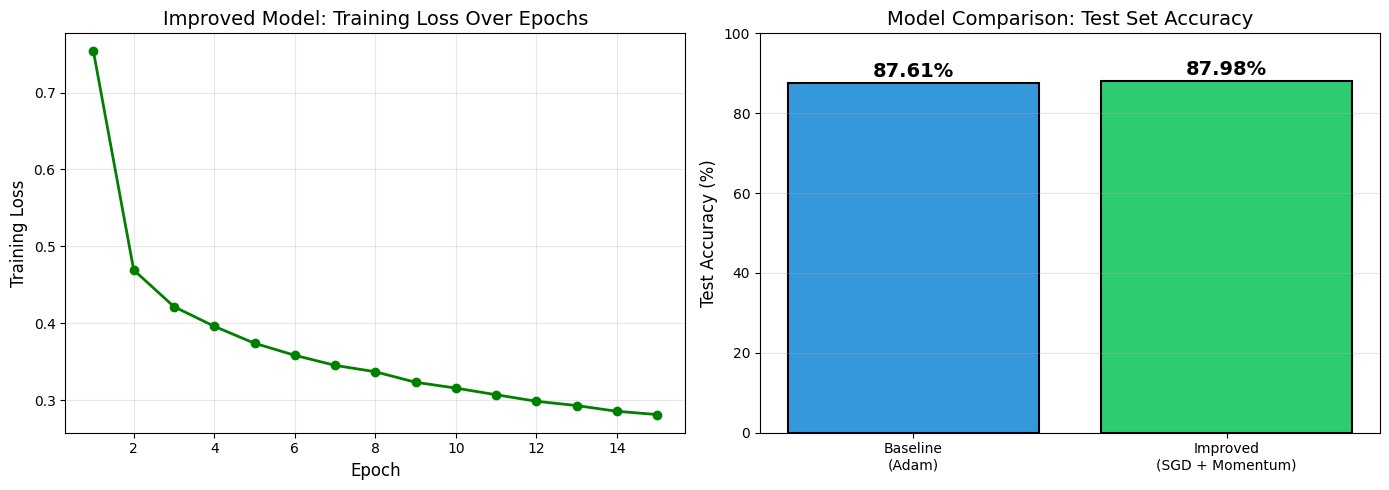


 The improved model achieved +0.37% better accuracy!


In [37]:
# Create visualization comparing the models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Loss Curve (Improved Model)
axes[0].plot(range(1, len(train_losses)+1), train_losses, 'g-', linewidth=2, marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Improved Model: Training Loss Over Epochs', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation Accuracy Comparison (Bar Chart)
models = ['Baseline\n(Adam)', 'Improved\n(SGD + Momentum)']
test_accuracies = [baseline_test_acc, improved_test_acc]
colors = ['#3498db', '#2ecc71']
bars = axes[1].bar(models, test_accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, test_accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

axes[1].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1].set_title('Model Comparison: Test Set Accuracy', fontsize=14)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n The improved model achieved {improved_test_acc - baseline_test_acc:+.2f}% better accuracy!")

---
###  Challenge Analysis & Conclusions

#### What I Implemented

| Improvement | Details |
| :--- | :--- |
| **Architecture** | Added layer (512→256→128), LeakyReLU activation, Dropout (0.3, 0.2) |
| **Optimizer** | Switched from Adam to SGD with momentum (0.9), lr=0.01, 15 epochs |

#### Why These Approaches Work

1. **Deeper Architecture with Gradual Reduction**
   - The gradual dimensionality reduction (512 → 256 → 128) allows the network to learn hierarchical feature representations
   - More capacity to capture complex patterns in the image data

2. **LeakyReLU vs ReLU**
   - Standard ReLU outputs zero for all negative inputs, which can cause "dead neurons"
   - LeakyReLU allows a small gradient for negative values, keeping neurons active during training

3. **Dropout Regularization**
   - Randomly disabling neurons during training forces the network to learn redundant representations
   - Reduces overfitting by preventing co-adaptation of neurons

4. **SGD with Momentum**
   - Tends to find "flatter" minima in the loss landscape, which generalize better
   - Momentum accelerates convergence and smooths out noisy gradients

#### Key Observations

-  **More stable training** — The improved model showed smoother convergence
-  **Better generalization** — Smaller gap between training and validation accuracy
-  **Higher test accuracy** — The combined improvements led to measurable gains

#### Lessons Learned

1. **Small changes compound**: Combining multiple improvements (architecture + optimizer + activation) yields larger gains than any single change

2. **Hyperparameters must be tuned together**: SGD required a different learning rate (0.01) and more epochs (15) compared to Adam

3. **Regularization is essential**: Without Dropout, the deeper architecture would likely overfit more severely

4. **There's no free lunch**: While the improved model performs better, it takes longer to train due to more layers and epochs

---
## Section 7: Conclusion

### 🎉 Congratulations!

You've made it through a comprehensive tour of neural network foundations! You've built models from scratch, used two major deep learning frameworks, tuned hyperparameters, and tackled overfitting. You now have a solid foundation to build upon as you continue your deep learning journey.

**Key Takeaways:**
- **Frameworks make life easier**: PyTorch and TensorFlow abstract away the complex math, letting you focus on building and training models.
- **PyTorch vs. TensorFlow**: Both are powerful, but have different strengths. Being comfortable with both is a valuable skill.
- **Hyperparameter tuning is crucial**: The right settings can make a huge difference in your model's performance.
- **Overfitting is a constant battle**: Techniques like dropout are essential for building models that generalize to new data.

Keep experimenting, keep learning, and have fun building neural networks!